<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/TimeA007.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

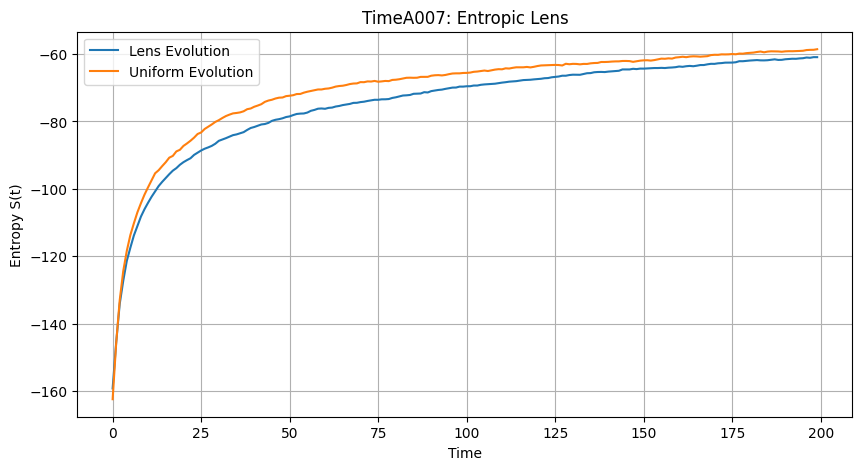

Lens Evolution Metrics:
Entropy Slope: 0.21743
Memory Retention: 0.99831
Irreversibility Index: 100.27510
Geometric Deformation: 0.26188

Uniform Evolution Metrics:
Entropy Slope: 0.19962
Memory Retention: 0.99793
Irreversibility Index: 108.89853
Geometric Deformation: 0.34140


In [1]:
# 🧭 TimeA007: The Entropic Lens
# Testing geometric deformation from localized entropy gradients
# Author: Chris & Copilot | Arc V: Entropic Ascent | ACT031
# Reproducibility Tag: TimeA007_v1

import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
N = 100  # lattice size
T = 200  # timesteps
curvature_strength = 0.5
xi_locking = True
bias_strength = 0.05
lens_radius = 20
seed = 42
np.random.seed(seed)

# --- Initialization ---
def initialize_lattice(N, curvature_strength):
    base = np.random.rand(N, N)
    curvature = curvature_strength * (np.sin(np.linspace(0, np.pi, N))[:, None])
    return base + curvature

# --- Entropy Calculation ---
def compute_entropy(lattice):
    hist, _ = np.histogram(lattice, bins=50, density=True)
    hist = hist[hist > 0]
    return -np.sum(hist * np.log(hist))

# --- Drift Calculation ---
def compute_drift(lattice, prev_lattice):
    return lattice - prev_lattice

# --- Lens Mask ---
def create_lens_mask(N, radius):
    x, y = np.meshgrid(np.arange(N), np.arange(N))
    center = N // 2
    mask = ((x - center)**2 + (y - center)**2) < radius**2
    return mask.astype(float)

# --- Evolution Functions ---
def evolve_lens(lattice, xi_locking, bias_strength, lens_mask):
    entropy_map = np.gradient(lattice)[0]
    bias_field = bias_strength * entropy_map * lens_mask
    lattice += 0.01 * np.random.randn(*lattice.shape) + bias_field
    if xi_locking:
        lattice = np.clip(lattice, 0.2, 0.8)
    return lattice

def evolve_uniform(lattice, xi_locking, bias_strength):
    entropy_map = np.gradient(lattice)[0]
    lattice += 0.01 * np.random.randn(*lattice.shape) + bias_strength * entropy_map
    if xi_locking:
        lattice = np.clip(lattice, 0.2, 0.8)
    return lattice

# --- Simulation Loop ---
def run_simulation(N, T, curvature_strength, xi_locking, bias_strength, lens=False):
    lattice = initialize_lattice(N, curvature_strength)
    lens_mask = create_lens_mask(N, lens_radius) if lens else np.ones((N, N))
    entropy_series = []
    cumulative_drift = np.zeros_like(lattice)
    for t in range(T):
        prev_lattice = lattice.copy()
        if lens:
            lattice = evolve_lens(lattice, xi_locking, bias_strength, lens_mask)
        else:
            lattice = evolve_uniform(lattice, xi_locking, bias_strength)
        cumulative_drift += compute_drift(lattice, prev_lattice)
        S = compute_entropy(lattice)
        entropy_series.append(S)
    return np.array(entropy_series), cumulative_drift

# --- Run Lens and Uniform ---
lens_entropy, lens_drift = run_simulation(N, T, curvature_strength, xi_locking, bias_strength, lens=True)
uniform_entropy, uniform_drift = run_simulation(N, T, curvature_strength, xi_locking, bias_strength, lens=False)

# --- Metrics ---
def compute_metrics(entropy_series, cumulative_drift):
    slope = np.polyfit(np.arange(len(entropy_series)), entropy_series, 1)[0]
    memory = np.corrcoef(entropy_series[:-1], entropy_series[1:])[0,1]
    irreversibility_index = np.sum(np.abs(np.diff(entropy_series)))
    deformation = np.std(cumulative_drift)
    return slope, memory, irreversibility_index, deformation

lens_metrics = compute_metrics(lens_entropy, lens_drift)
uniform_metrics = compute_metrics(uniform_entropy, uniform_drift)

# --- Plotting ---
plt.figure(figsize=(10,5))
plt.plot(lens_entropy, label='Lens Evolution')
plt.plot(uniform_entropy, label='Uniform Evolution')
plt.xlabel('Time')
plt.ylabel('Entropy S(t)')
plt.title('TimeA007: Entropic Lens')
plt.legend()
plt.grid(True)
plt.show()

# --- Output ---
print("Lens Evolution Metrics:")
print(f"Entropy Slope: {lens_metrics[0]:.5f}")
print(f"Memory Retention: {lens_metrics[1]:.5f}")
print(f"Irreversibility Index: {lens_metrics[2]:.5f}")
print(f"Geometric Deformation: {lens_metrics[3]:.5f}")

print("\nUniform Evolution Metrics:")
print(f"Entropy Slope: {uniform_metrics[0]:.5f}")
print(f"Memory Retention: {uniform_metrics[1]:.5f}")
print(f"Irreversibility Index: {uniform_metrics[2]:.5f}")
print(f"Geometric Deformation: {uniform_metrics[3]:.5f}")
